In [29]:
import numpy as np
from salem import open_wrf_dataset
import matplotlib
from IPython.display import display
from pathlib import Path
import matplotlib.pyplot as plt

matplotlib.rcParams.update({'font.size': 16})

In [37]:
graphs_dir = Path("graphs")
data_path = Path('results').joinpath('wrfout_d02_selcomb022.nc').resolve()

ds = open_wrf_dataset(data_path)
display(ds.to_dataframe().tail())

LANDMASK  LU_INDEX          MU  \
time south_north west_east bottom_top                                   
35   -4053605.0  274000.0  39               0.0      17.0  598.555603   
                           40               0.0      17.0  598.555603   
                           41               0.0      17.0  598.555603   
                           42               0.0      17.0  598.555603   
                           43               0.0      17.0  598.555603   

                                              P            PHB           PSFC  \
time south_north west_east bottom_top                                           
35   -4053605.0  274000.0  39         -0.680720  155080.250000  100936.914062   
                           40         -0.396340  163999.593750  100936.914062   
                           41         -0.352813  172918.937500  100936.914062   
                           42         -0.499342  181838.265625  100936.914062   
                           43          1.554795  190757.593750  100936.914062   

                                         QVAPOR         SST          T2  \
time south_north west_east bottom_top                                     
35   -4053605.0  274000.0  39          0.000003  283.622131  285.127686   
                           40          0.000002  283.622131  285.127686   
                           41          0.000002  283.622131  285.127686   
                           42          0.000002  283.622131  285.127686   
                           43          0.000001  283.622131  285.127686   

                                              TSK       U10        V10  XLAND  \
time south_north west_east bottom_top                                           
35   -4053605.0  274000.0  39          283.622131  2.200886  10.342556    2.0   
                           40          283.622131  2.200886  10.342556    2.0   
                           41          283.622131  2.200886  10.342556    2.0   
                           42          283.622131  2.200886  10.342556    2.0   
                           43          283.622131  2.200886  10.342556    2.0   

                                             T2C        lat       lon  \
time south_north west_east bottom_top                                   
35   -4053605.0  274000.0  39          11.977692  49.698452 -48.86702   
                           40          11.977692  49.698452 -48.86702   
                           41          11.977692  49.698452 -48.86702   
                           42          11.977692  49.698452 -48.86702   
                           43          11.977692  49.698452 -48.86702   

                                           xtime  
time south_north west_east bottom_top             
35   -4053605.0  274000.0  39         2019-09-06  
                           40         2019-09-06  
                           41         2019-09-06  
                           42         2019-09-06  
                           43         2019-09-06

### Variables at the End

In [31]:
u = ds.U10.sel(time=35)
v = ds.V10.sel(time=35)
"Temperature"
stb = ds.T2.sel(time=0)
st = ds.T2.sel(time=35)

"Top Pressure"
sp = ds.P.sel(time=35).sel(bottom_top=15)
"Surface Pressure"
psfc = ds.PSFC.sel(time=35)
"Water Vapor"
watervapor = ds.QVAPOR.sel(time=35).sel(bottom_top=10)
"SST"
sst = ds.SST.sel(time=35)

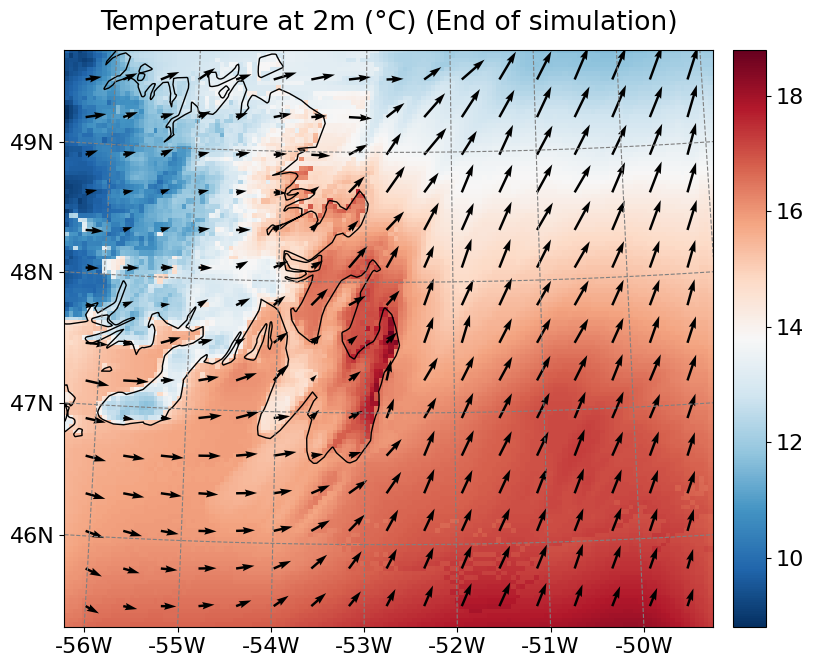

In [32]:
f, ax = plt.subplots(figsize=(9.5, 7.5))

# plot the salem map background, make countries in grey
smap = st.salem.get_map(cmap='RdBu_r')
smap.set_data(st - 273.15, crs=ds.salem.grid)

us = u[4::8, 4::8]
vs = v[4::8, 4::8]

# transform their coordinates to the map reference system and plot the arrows
xx, yy = smap.grid.transform(us.west_east.values, us.south_north.values,
                             crs=us.salem.grid.proj)
xx, yy = np.meshgrid(xx, yy)
qu = ax.quiver(xx, yy, us.values, vs.values)
qk = plt.quiverkey(qu, 0.5, 0.965, 10, 'wind direction', labelpos='W', coordinates='figure')
smap.visualize()
ax.set_title('Temperature at 2m (°C) (End of simulation)', y=1.02)
plt.savefig(graphs_dir.joinpath('temperature_end.pdf').resolve(), dpi=300)
plt.show()

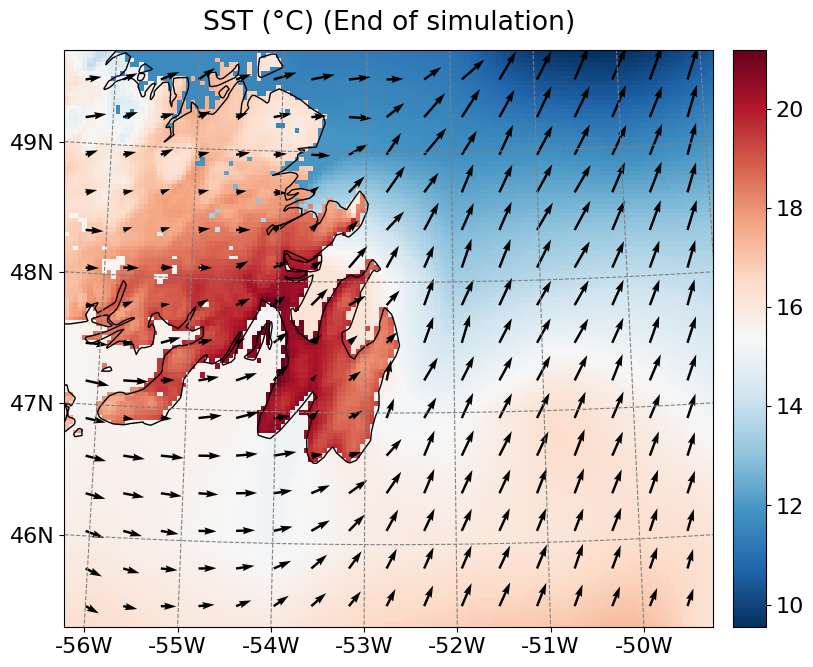

In [33]:
f, ax = plt.subplots(figsize=(9.5, 7.5))

# plot the salem map background, make countries in grey
smap = sst.salem.get_map(cmap='RdBu_r')
smap.set_data(sst - 273.15, crs=ds.salem.grid)

us = u[4::8, 4::8]
vs = v[4::8, 4::8]

# transform their coordinates to the map reference system and plot the arrows
xx, yy = smap.grid.transform(us.west_east.values, us.south_north.values,
                             crs=us.salem.grid.proj)
xx, yy = np.meshgrid(xx, yy)
qu = ax.quiver(xx, yy, us.values, vs.values)
qk = plt.quiverkey(qu, 0.5, 0.965, 10, 'wind direction', labelpos='W', coordinates='figure')
smap.visualize()
ax.set_title('SST (°C) (End of simulation)', y=1.02)
plt.savefig(graphs_dir.joinpath('sst_end.pdf').resolve(), dpi=300)
plt.show()

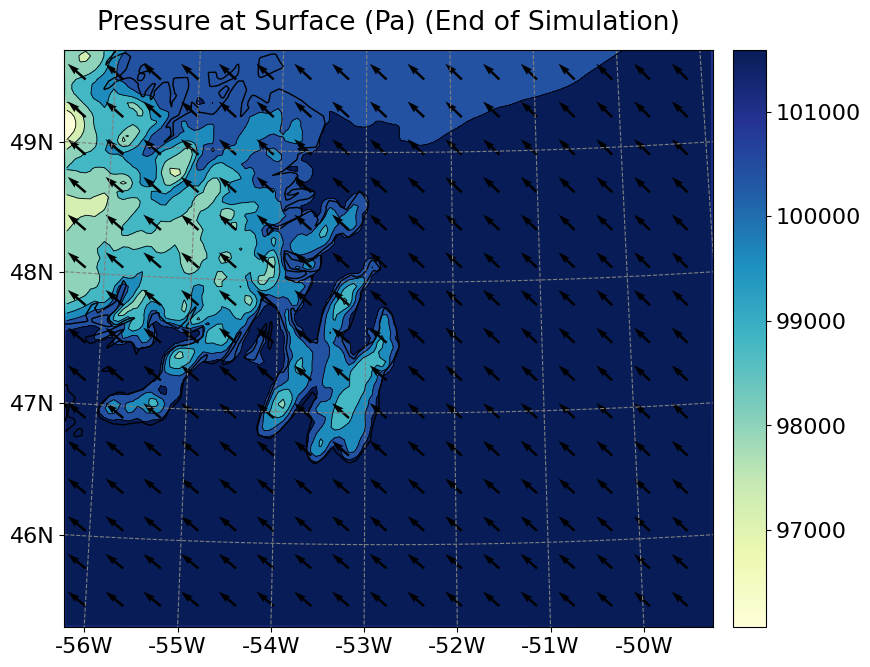

In [34]:
f, ax = plt.subplots(figsize=(9.5, 7.5))

# plot the salem map background, make countries in grey
smap = psfc.salem.get_map(cmap='YlGnBu')
smap.set_data(psfc, crs=ds.salem.grid)

# # transform their coordinates to the map reference system and plot the arrows
pu = psfc.lon[4::8, 4::8]
pv = psfc.lat[4::8, 4::8]

xx, yy = smap.grid.transform(psfc.west_east.values, psfc.south_north.values,
                             crs=psfc.salem.grid.proj)

qc = ax.contourf(xx, yy, psfc, cmap='YlGnBu', extend="both",
                 vmin=psfc.min(), vmax=psfc.max())
ql = ax.contour(xx, yy, psfc, colors='k', linewidths=0.6)

xx, yy = smap.grid.transform(pu.west_east.values, pu.south_north.values,
                             crs=psfc.salem.grid.proj)
xx, yy = np.meshgrid(xx, yy)
qu = ax.quiver(xx, yy, pu.values, pv.values)
qk = plt.quiverkey(qu, 0.5, 0.965, 200, 'pressure increase', labelpos='W', coordinates='figure')

ax.set_title('Pressure at Surface (Pa) (End of Simulation)', y=1.02)
smap.visualize()
plt.savefig(graphs_dir.joinpath('pressure_surface_end.pdf').resolve(), dpi=300)
plt.show()

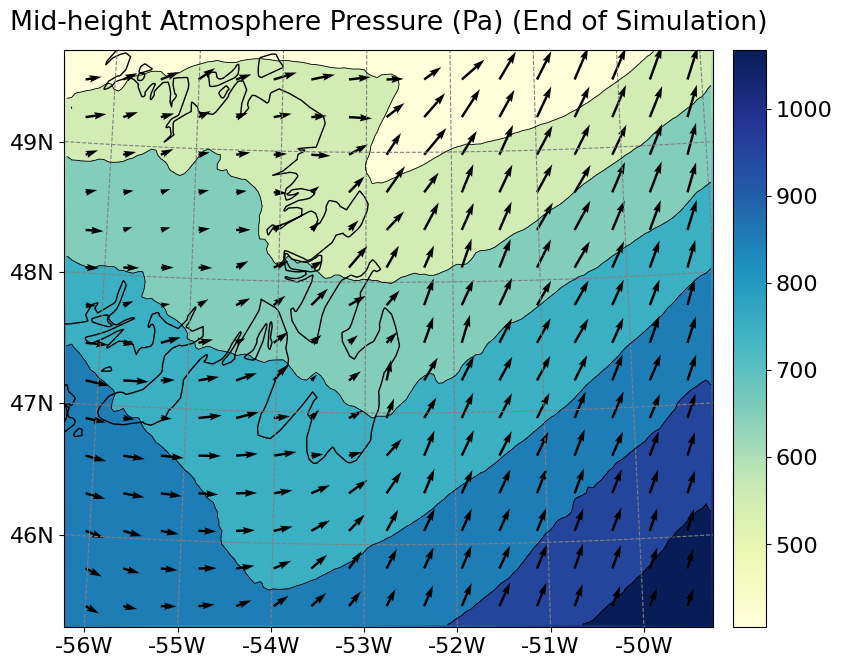

In [35]:
f, ax = plt.subplots(figsize=(9.5, 7.5))

# plot the salem map background, make countries in grey
smap = sp.salem.get_map(cmap='YlGnBu')
smap.set_data(sp, crs=ds.salem.grid)

us = u[4::8, 4::8]
vs = v[4::8, 4::8]

# transform their coordinates to the map reference system and plot the arrows
xx, yy = smap.grid.transform(sp.west_east.values, sp.south_north.values,
                             crs=sp.salem.grid.proj)
qc = ax.contourf(xx, yy, sp, cmap='YlGnBu', extend="both",vmin=sp.min()+.8, vmax=sp.max()-.9)
ql = ax.contour(xx, yy, sp, colors='k', linewidths=0.6)

xx, yy = smap.grid.transform(us.west_east.values, us.south_north.values,
                             crs=us.salem.grid.proj)
xx, yy = np.meshgrid(xx, yy)
qu = ax.quiver(xx, yy, us.values, vs.values)
qk = plt.quiverkey(qu, 0.5, 0.965, 10, 'wind direction', labelpos='W', coordinates='figure')
ax.set_title('Mid-height Atmosphere Pressure (Pa) (End of Simulation)', y=1.02)
smap.visualize()
plt.savefig(graphs_dir.joinpath('pressure_top_end.pdf').resolve(), dpi=300)
plt.show()

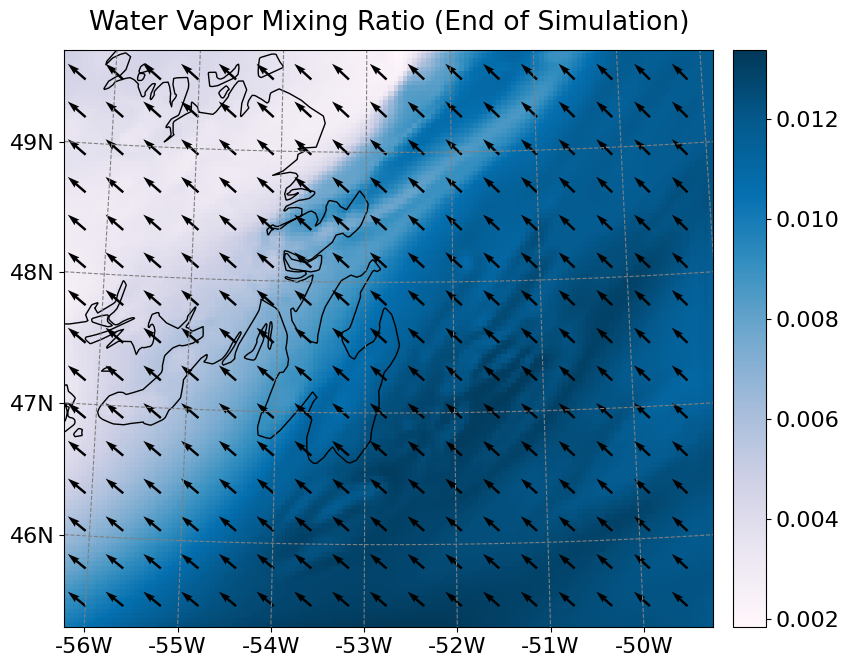

In [36]:
f, ax = plt.subplots(figsize=(9.5, 7.5))

# plot the salem map background, make countries in grey
smap = watervapor.salem.get_map(cmap='PuBu')
smap.set_data(watervapor, crs=ds.salem.grid)

us = watervapor.lon[4::8, 4::8]
vs = watervapor.lat[4::8, 4::8]

xx, yy = smap.grid.transform(us.west_east.values, us.south_north.values,
                             crs=watervapor.salem.grid.proj)
xx, yy = np.meshgrid(xx, yy)
qu = ax.quiver(xx, yy, us.values, vs.values)
qk = plt.quiverkey(qu, 0.5, 0.965, 200, 'ratio decrease', labelpos='W', coordinates='figure' )

ax.set_title('Water Vapor Mixing Ratio (End of Simulation)', y=1.02)
smap.visualize()
plt.savefig(graphs_dir.joinpath('watorvapor_surface_end.pdf').resolve(), dpi=300)
plt.show()